In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from keras import Sequential, Input
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.metrics import Precision, Recall
from sklearn.pipeline import Pipeline


!pip -q install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Install explainability libraries
!pip install shap lime
import shap
import lime
import lime.lime_tabular


# NN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from tensorflow.keras import layers


2025-10-21 16:33:50.956054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761064431.174329      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761064431.235969      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.9 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/kaggle/input/airlinedatasetcleaned/AirlineScrappedReview_Cleaned.csv")

<Axes: >

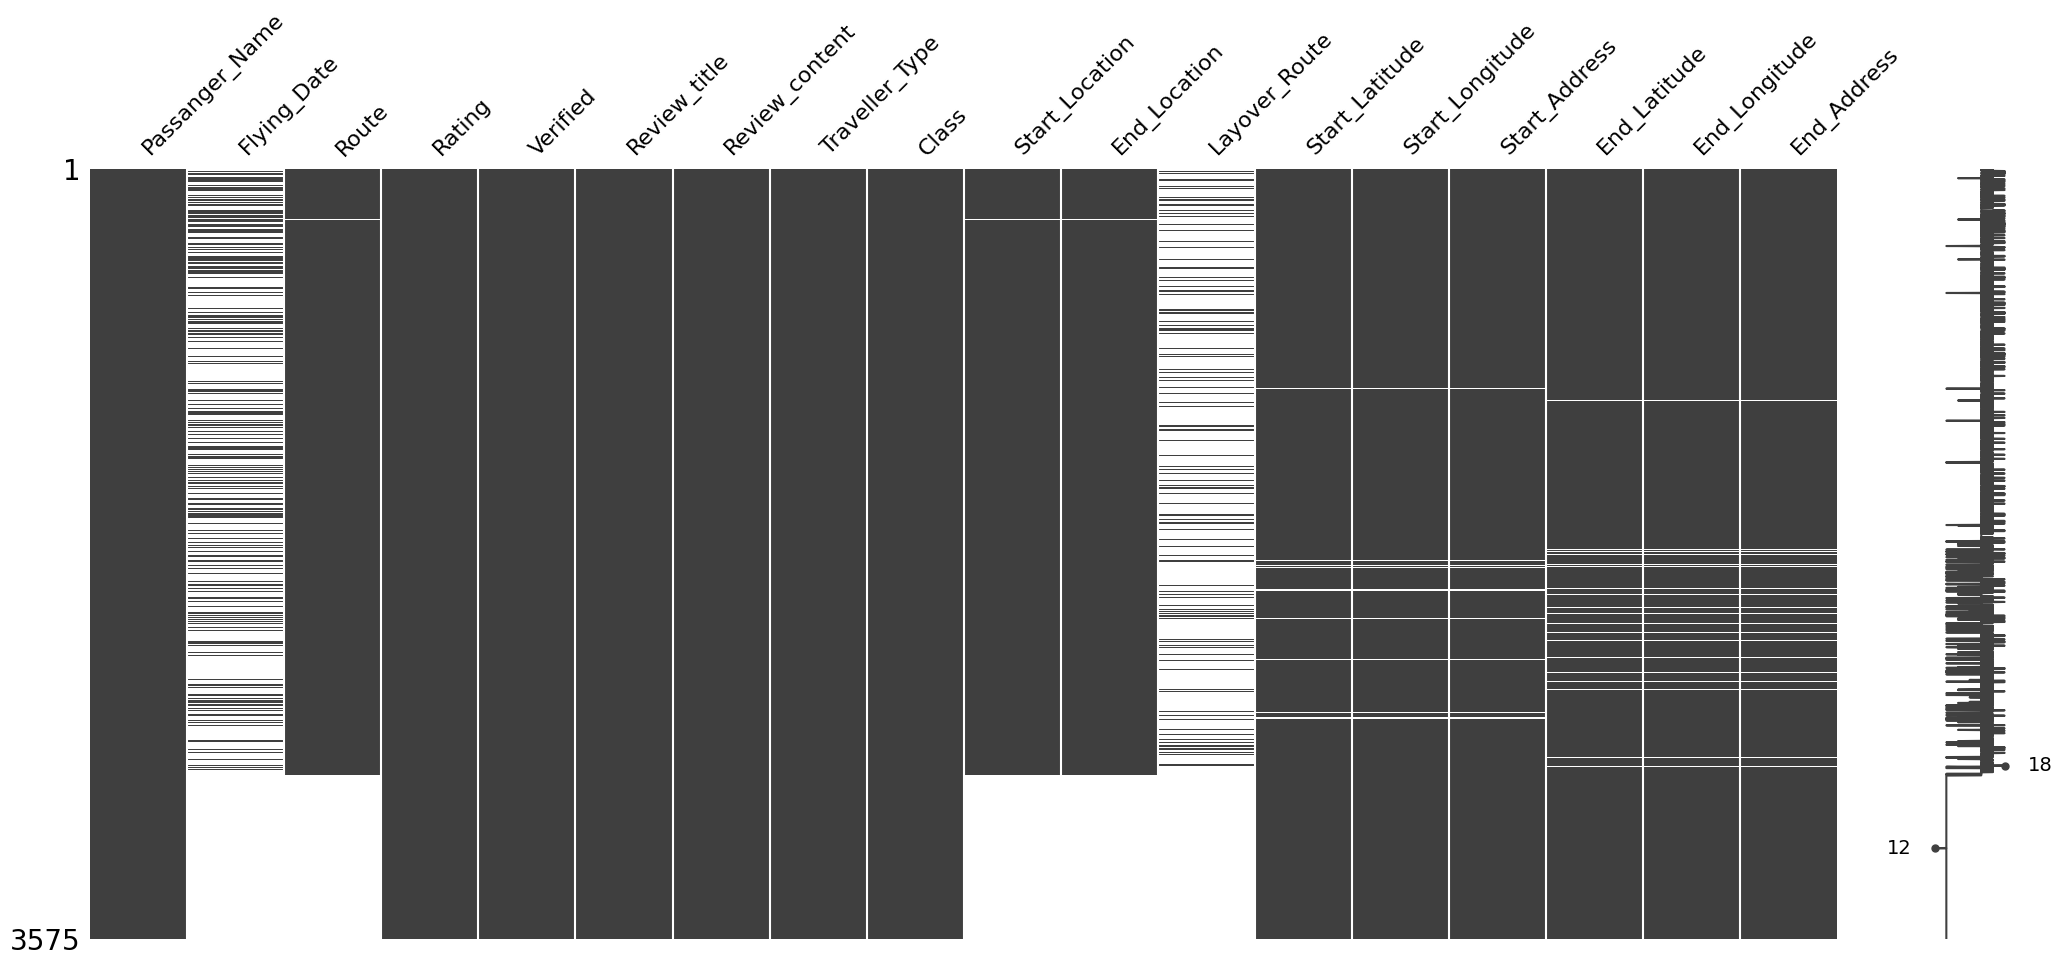

In [3]:
msno.matrix(df)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3574 non-null   object 
 1   Flying_Date      955 non-null    object 
 2   Route            2809 non-null   object 
 3   Rating           3575 non-null   int64  
 4   Verified         3575 non-null   object 
 5   Review_title     3575 non-null   object 
 6   Review_content   3575 non-null   object 
 7   Traveller_Type   3575 non-null   object 
 8   Class            3575 non-null   object 
 9   Start_Location   2809 non-null   object 
 10  End_Location     2809 non-null   object 
 11  Layover_Route    484 non-null    object 
 12  Start_Latitude   3515 non-null   float64
 13  Start_Longitude  3515 non-null   float64
 14  Start_Address    3515 non-null   object 
 15  End_Latitude     3476 non-null   float64
 16  End_Longitude    3476 non-null   float64
 17  End_Address   

## 🧠 Sentiment Extraction from Review Text

**Purpose.**  
Create **sentiment features** from the Review_content column to capture passengers’ expressed opinions and use them later as predictive signals.

**What this cell does**
**Run VADER sentiment analysis.**  
   - Uses `vaderSentiment.SentimentIntensityAnalyzer()` designed for short, social-style English text.  
   - Computes the score in `[-1, 1]` (negative → positive).  
   - Adds two features:
     - `Sentiment` (categorical label):  
       - `Positive` if compound ≥ **0.05**  
       - `Negative` if compound ≤ **-0.05**  
       - `Neutral` otherwise  
       *(These are the standard VADER thresholds.)*
     - `Sentiment_Score` (continuous): the raw compound score for finer-grained modeling.

**Output columns added.**
- `Sentiment` ∈ {Negative, Neutral, Positive}  
- `Sentiment_Score` ∈ [-1.0, 1.0]

**File written.**  
- `AirlineScrappedReview_Sentiment.csv`

In [5]:
# Prepare text (handle NaNs / whitespace)
text_col = "Review_content" if "Review_content" in df.columns else "review_content"
if text_col not in df.columns:
    raise KeyError(f"Couldn't find a review text column. Expected 'Review_Content' (or 'review_content'). Columns found: {list(df.columns)}")

df[text_col] = df[text_col].astype(str).fillna("").str.strip()

# Create the analyzer and add ONE sentiment column (label only)
analyzer = SentimentIntensityAnalyzer()

def label_sentiment(text: str) -> str:
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df[text_col].apply(label_sentiment)
df["Sentiment_Score"] = df[text_col].apply(lambda t: analyzer.polarity_scores(t)['compound'])


# Save the augmented file 
out_path = "AirlineScrappedReview_Sentiment.csv"
df.to_csv(out_path, index=False)
print(f"Saved with Sentiment column ➜ {out_path}")

Saved with Sentiment column ➜ AirlineScrappedReview_Sentiment.csv


## Cleaning Categorical Fields: Removing `"Unknown"` for Traveller_Type & Class

**Purpose.**  
This step standardizes the `Traveller_Type` and `Class` columns by replacing all `"Unknown"` values with the **most frequent valid category** (mode).  
It ensures both columns have consistent, meaningful entries before modeling.


**What this cell does.**
- Detects and removes stray spaces or inconsistent casing.  
- Identifies `"Unknown"` entries.  
- Replaces them with the most common valid value in the column.  

**Why this is needed.**
- `"Unknown"` is not a meaningful category; treating it as a real class can mislead both statistics and ML.  
- Mode imputation preserves the column’s distribution better than dropping rows and avoids leakage from using the target for imputation.

**Effects on the data.**
- Reduces or removes the `"Unknown"` data, reallocating those rows to the most representative valid category.   

**Output file.**  
- `AirlineScrappedReview_Cleaned_All.csv`


In [6]:
for col in ['Traveller_Type', 'Class']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        known_mask = df[col].str.casefold() != 'unknown'
        if known_mask.any():
            mode_val = df.loc[known_mask, col].mode().iloc[0]
            df.loc[~known_mask, col] = mode_val

# --- Save cleaned CSV ---
out_path = "AirlineScrappedReview_Cleaned_All.csv"
df.to_csv(out_path, index=False)
print(f"Saved cleaned file to: {out_path}")


Saved cleaned file to: AirlineScrappedReview_Cleaned_All.csv


### Data Engineering:Traveler Type and Class Combination

**Question:**  
By analyzing review patterns, which traveler type and class combination yields the highest and lowest ratings?

**Method:**  
The dataset was grouped by `Traveller_Type` and `Class`, and the **average rating** was computed for each combination.  
This allows us to identify which passenger group tends to be most or least satisfied based on their reviews.

**Findings:**
  **Highest Rated Combination:**  
  - **Traveler Type:** Solo Leisure  
  - **Class:** First Class  
  - **Average Rating:** 6.63  

  Solo leisure travelers in First Class gave the **highest satisfaction ratings**, likely due to personalized service and comfort provided to individual travelers.

 **Lowest Rated Combination:**  
  - **Traveler Type:** Various  
  - **Class:** Economy Class  
  - **Average Rating:** 1.00  

  The lowest ratings came from travelers classified as “Various” in Economy Class, which may include mixed travel groups or unclear purposes.  
  This suggests that inconsistent service experiences or differing expectations may lead to lower satisfaction in this group.


In [7]:
#Group by traveler type and seat type
grouped = df.groupby(['Traveller_Type', 'Class'])['Rating'].mean().reset_index()

# Sort to identify highest and lowest
highest = grouped.loc[grouped['Rating'].idxmax()]
lowest = grouped.loc[grouped['Rating'].idxmin()]

print("Highest Rated Combination:")
print(highest)

print("\nLowest Rated Combination:")
print(lowest)

Highest Rated Combination:
Traveller_Type    Solo Leisure
Class              First Class
Rating                6.627907
Name: 14, dtype: object

Lowest Rated Combination:
Traveller_Type          Various
Class             Economy Class
Rating                      1.0
Name: 16, dtype: object


### Data Engineering: Top 10 Most Popular Flight Routes

**Question:**  
What are the top 10 most popular flight routes?

**Data Source Used:**  
Instead of using the `route` column from the *AirlineScrappedReview_Cleaned.csv* file, we used the **`Passanger_booking_data.csv`** file.  
The decision was made because:
- The `route` column in the review dataset had *766 missing values out of 3,575 total rows*,  
  making it **incomplete** for meaningful analysis.
- It was also a **text-based column**, which prevents statistical operations such as mean or mode imputation.
- Including such incomplete data would negatively impact model accuracy and feature reliability.

In contrast, the **booking dataset’s `route` column contained no null values** and provided a clean, structured record of flight routes actually booked which makes it ideal for analysis.

**Approach:**
1. Loaded the booking data from `Passanger_booking_data.csv`.  
2. Cleaned the `route` column by removing blank and whitespace-only entries.  
3. Counted the number of bookings per route using `value_counts()`.  
4. Selected and visualized the **Top 10 routes** based on booking frequency.
**Results:**
| Rank | Route Code | Route (From → To) | Number of Bookings |
|------|-------------|------------------|--------------------|
| 1 | **AKLKUL** | **Auckland (New Zealand)** → **Kuala Lumpur (Malaysia)** | **2,680** |
| 2 | **PENTPE** | **Penang (Malaysia)** → **Taipei (Taiwan)** | **924** |
| 3 | **MELSGN** | **Melbourne (Australia)** → **Ho Chi Minh City (Vietnam)** | **842** |
| 4 | **ICNSIN** | **Incheon/Seoul (South Korea)** → **Singapore (Singapore)** | **801** |
| 5 | **DMKKIX** | **Bangkok Don Mueang (Thailand)** → **Osaka Kansai (Japan)** | **744** |
| 6 | **ICNSYD** | **Incheon/Seoul (South Korea)** → **Sydney (Australia)** | **695** |
| 7 | **DMKPER** | **Bangkok Don Mueang (Thailand)** → **Perth (Australia)** | **679** |
| 8 | **DPSICN** | **Denpasar/Bali (Indonesia)** → **Incheon/Seoul (South Korea)** | **666** |
| 9 | **DMKOOL** | **Bangkok Don Mueang (Thailand)** → **Gold Coast (Australia)** | **655** |
| 10 | **MELPEN** | **Melbourne (Australia)** → **Penang (Malaysia)** | **649** |


**Interpretation:**
The most frequently booked route is **Auckland → Kuala Lumpur** with **2,680 bookings**, followed by **Penang → Taipei**, **Melbourne → Ho Chi Minh City**, and **Incheon → Singapore**.  

Top 10 Most Popular Flight Routes:
 route  Bookings
AKLKUL      2680
PENTPE       924
MELSGN       842
ICNSIN       801
DMKKIX       744
ICNSYD       695
DMKPER       679
DPSICN       666
DMKOOL       655
MELPEN       649


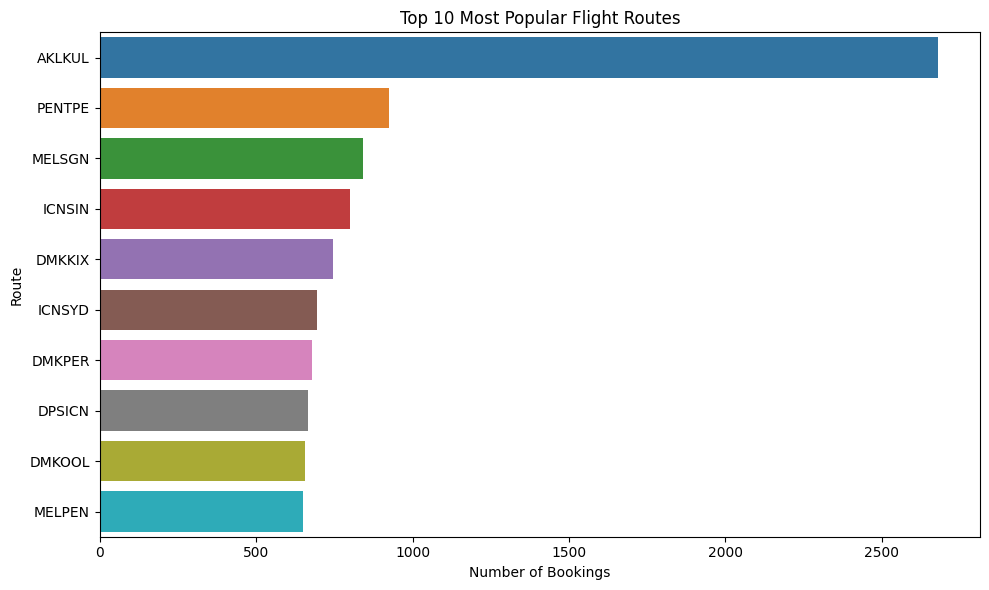

In [9]:
df2 = pd.read_csv("/kaggle/input/airline-passangers-booking-data/Passanger_booking_data.csv")

# Clean Route column (remove NaNs/blank/whitespace-only)
df2['route'] = df2['route'].astype(str).str.strip()
df2 = df2[df2['route'].notna() & (df2['route'] != '')]

# Compute Top 10 routes 
top_routes = df2['route'].value_counts().head(10).reset_index()
top_routes.columns = ['route', 'Bookings']

# Print results 
print("Top 10 Most Popular Flight Routes:")
print(top_routes.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=top_routes, x='Bookings', y='route')
plt.title("Top 10 Most Popular Flight Routes")
plt.xlabel("Number of Bookings")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

### Data Engineering: Distribution of Bookings Across Flight Hours

**Question:**  
What is the distribution of bookings across flight hours?

**Approach:**
1. Converted the `flight_hour` column to a numeric data type to ensure consistency.  
2. Dropped any rows with missing or invalid hour values.  
3. Counted the total number of bookings for each flight hour.  
4. Visualized the results as a bar chart to show hourly trends.

**Results:**
The analysis shows the following **distribution of bookings across flight hours**:

| Flight Hour | Bookings |
|--------------|-----------|
| 0–2 | Gradual increase, starting from 1,539 at midnight to 2,642 at 2 AM |
| 3–6 | Significant rise, peaking at 3,051 bookings around 6 AM |
| 7–13 | Consistently high booking volume between 3,100–3,165 bookings |
| 14–16 | Gradual decline in the afternoon (down to around 1,500 by 4 PM) |
| 17–23 | Noticeable drop in evening and late-night hours, reaching a low of 276 at 8 PM before a slight recovery around 11 PM |

**Insights:**
- The **busiest flight hours** are between **6 AM and 1 PM**, showing peak demand during the **morning and mid-day travel window**.
- Booking activity **declines sharply after 4 PM**, likely due to fewer scheduled flights.
- These results suggest airlines schedule most flights during **daylight hours** when passenger demand is highest, and fewer flights operate overnight.


Booking distribution by flight hour:
flight_hour
0     1539
1     2089
2     2642
3     2655
4     2843
5     2851
6     3051
7     3126
8     3165
9     3133
10    3085
11    3110
12    3163
13    3101
14    2833
15    2234
16    1557
17     861
18     439
19     295
20     276
21     389
22     579
23     986
Name: count, dtype: int64


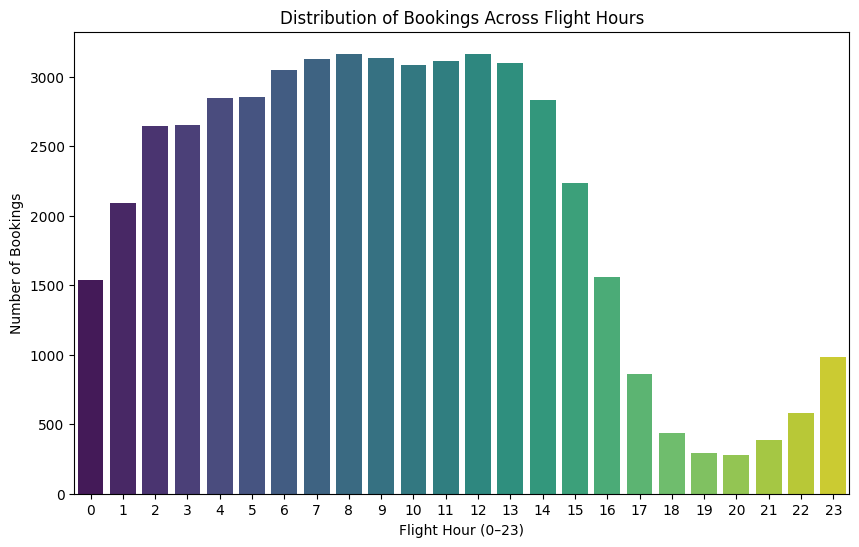

In [10]:
df2['flight_hour'] = pd.to_numeric(df2['flight_hour'], errors='coerce')

# Drop missing hours if any
df2 = df2.dropna(subset=['flight_hour'])

# Group by flight hour
hourly_bookings = df2['flight_hour'].value_counts().sort_index()

print("Booking distribution by flight hour:")
print(hourly_bookings)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=hourly_bookings.index, y=hourly_bookings.values, palette='viridis')
plt.title("Distribution of Bookings Across Flight Hours")
plt.xlabel("Flight Hour (0–23)")
plt.ylabel("Number of Bookings")
plt.xticks(range(0,24))
plt.show()

### Data Cleaning: Handling Missing Passenger Names

**Purpose.**  
This step ensures that every passenger record contains a valid name, maintaining dataset consistency and avoiding issues in later processing.

**What this cell does.**
- Checks if the column `Passanger_Name` exists.  
- Detects any missing or blank entries (including whitespace-only rows).  
- Replaces all such missing names with a placeholder value **"Amina Tamer"**.  
- Saves the cleaned dataset to a new CSV file.

**Why this is needed.**
- The column had **only one missing name**, which did not justify dropping the entire record or column.  
- Using a placeholder preserves the data integrity and prevents loss of potentially useful information.

**Effects on the data.**
- All rows now have complete `Passanger_Name` entries.  
- The dataset is fully consistent and ready for the next preprocessing stages.

**Output file.**  
- `AirlineScrappedReview_Cleaned_All.csv`


In [11]:
# Check if the column exists
if 'Passanger_Name' not in df.columns:
    raise KeyError(f"Couldn't find a 'Name' column. Columns found: {list(df.columns)}")

# Fill null or missing names with "Amina Tamer"
df['Passanger_Name'] = df['Passanger_Name'].fillna('Amina Tamer')

# Optional: also replace empty strings or spaces with "Amina Tamer"
df['Passanger_Name'] = df['Passanger_Name'].replace(r'^\s*$', 'Amina Tamer', regex=True)

# Save the cleaned CSV
out_path = "AirlineScrappedReview_Cleaned_All.csv"
df.to_csv(out_path, index=False)

print(f"Saved cleaned file with missing names replaced ➜ {out_path}")

Saved cleaned file with missing names replaced ➜ AirlineScrappedReview_Cleaned_All.csv


## Data Cleaning: Dropping Incomplete & Unneeded Columns

**Purpose.**  
Remove columns that are largely missing or not required for modeling to reduce noise, prevent leakage, and simplify the dataset.

**What this cell does.**
- Identifies and drops the following columns if they exist:
  - `Flying_Date`, `Start_Location`, `End_Location`, `Layover_Route`,
    `Start_Latitude`, `Start_Longitude`, `Start_Address`,
    `End_Latitude`, `End_Longitude`, `End_Address`.
- Safely checks column existence to avoid errors.
- Saves the cleaned dataset once.

**Why this is needed.**
- `Flying_Date` contained **~73% null values**, making it unreliable for analysis or modeling.
- The remaining route/geo fields were **incomplete** and **not needed** for training the satisfaction model; keeping them could add noise and complicate preprocessing without improving performance.

**Effects on the data.**
- Fewer columns with missing or irrelevant information.
- A leaner feature set focused on variables that are complete and useful for prediction.

**Output file.**  
- `AirlineScrappedReview_Cleaned_All.csv`


In [12]:
cols_to_drop = [
    'Flying_Date',
    'Start_Location',
    'End_Location',
    'Layover_Route',
    'Start_Latitude',
    'Start_Longitude',
    'Start_Address',
    'End_Latitude',
    'End_Longitude',
    'End_Address'
]

# Keep only columns that actually exist to avoid KeyError
existing_to_drop = [c for c in cols_to_drop if c in df.columns]
if existing_to_drop:
    df = df.drop(columns=existing_to_drop)
    print(f"Dropped columns: {existing_to_drop}")
else:
    print("No matching columns found to drop.")

# Re-save (same filename as before, or change if you want a separate version)
out_path = "AirlineScrappedReview_Cleaned_All.csv"  # or your previous out_path
df.to_csv(out_path, index=False)
print(f"Saved cleaned file (after drops) ➜ {out_path}")

Dropped columns: ['Flying_Date', 'Start_Location', 'End_Location', 'Layover_Route', 'Start_Latitude', 'Start_Longitude', 'Start_Address', 'End_Latitude', 'End_Longitude', 'End_Address']
Saved cleaned file (after drops) ➜ AirlineScrappedReview_Cleaned_All.csv


## Encoding Categorical Columns for Modeling

**Purpose**  
Convert text categories into **deterministic numeric codes** so the neural network can consume them reliably and reproducibly.

**What this cell does**
- Defines explicit, human-readable → integer mappings for:
  - `Class` → `Class_enc` (Economy=0, Premium Economy=1, Business=2, First=3)
  - `Verified` → `Verified_enc` (Not Verified=0, Trip Verified=1)
  - `Sentiment` → `Sentiment_enc` (Negative=0, Neutral=1, Positive=2)
  - `Traveller_Type` → `Traveller_Type_enc` (Solo Leisure=0, Couple Leisure=1, Family Leisure=2, Business=3, Various=4)
- Applies these mappings to create new `*_enc` columns **without overwriting** the original text columns.
- Saves the encoded dataset to a new CSV.

**Effects on the data**
- Adds four integer columns: `Class_enc`, `Verified_enc`, `Sentiment_enc`, `Traveller_Type_enc`.
- Original categorical columns remain intact for plots and explanations.
- Downstream steps (scaling, training, inference) use the `*_enc` features consistently.

**Output file**  
- `AirlineScrappedReview_Encoded.csv`


In [13]:
# 1) Define explicit mappings
class_map = {
    "Economy Class": 0,
    "Premium Economy": 1,
    "Business Class": 2,
    "First Class": 3,
}

verified_map = {
    "Not Verified": 0,
    "Trip Verified": 1,
}

sentiment_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}

trav_map = {
    "Solo Leisure": 0,
    "Couple Leisure": 1,
    "Family Leisure": 2,
    "Business": 3,
    "Various": 4,
}

# 2) Apply mappings (keep originals; add *_enc columns)
if "Class" in df.columns:
    df["Class_enc"] = df["Class"].map(class_map)

if "Verified" in df.columns:
    df["Verified_enc"] = df["Verified"].map(verified_map)

if "Sentiment" in df.columns:
    df["Sentiment_enc"] = df["Sentiment"].map(sentiment_map)

if "Traveller_Type" in df.columns:
    df["Traveller_Type_enc"] = df["Traveller_Type"].map(trav_map)

out_path = "AirlineScrappedReview_Encoded.csv"  
df.to_csv(out_path, index=False)
print(f"Saved CSV with encoded columns ➜ {out_path}")

Saved CSV with encoded columns ➜ AirlineScrappedReview_Encoded.csv


## Feature Engineering and Model Training

### **Feature Engineering**

**Understanding the step**  
Feature engineering focuses on selecting and transforming the most relevant variables (`Traveller_Type_enc`, `Class_enc`, `Verified_enc`, and `Sentiment_enc`) to predict passenger satisfaction.  
Each selected feature captures a unique behavioral or contextual aspect of the traveler.
for example, traveler type reflects travel purpose, sentiment represents emotional tone, and verification status indicates review authenticity.

**Need for the step**  
This step is essential because neural networks require clean, numerical, and well-scaled inputs. Encoded features ensure consistent numerical representation across training and inference while scaling normalizes value ranges to stabilize gradient updates.

**Effect on the data**  
- Data is standardized to have a mean of 0 and standard deviation of 1.  
- Feature scaling minimizes bias caused by different feature magnitudes.  
- Encoded columns replace textual data, simplifying model computation and improving convergence stability.


### **Prediction Model**

**The model choice**  
Two **Feedforward Neural Networks (FFNNs)** were implemented:
1. **FFNN_Small (16–8)**: A lightweight architecture for faster training and lower computational cost.  
2. **FFNN_Large (64–32–16)**: A deeper model designed to capture more complex relationships between encoded travel and review features.

**How it works**  
- Each FFNN takes the scaled numerical inputs and passes them through dense (fully connected) layers with **ReLU** activation functions.  
- The network learns feature interactions and outputs a probability (via **sigmoid**) of whether a passenger is satisfied (`Satisfied = 1`) or dissatisfied (`Satisfied = 0`).  
- **Binary cross-entropy** is used as the loss function, with **Adam** optimizer handling weight updates.  
- **EarlyStopping** prevents overfitting by halting training when validation accuracy stops improving.

**Model performance**  
The best performance was achieved with **Feature Set F** (`Verified_enc`, `Traveller_Type_enc`, `Class_enc`, `Sentiment_enc`) using the **FFNN_Large (64–32–16)** model, yielding:
- **Accuracy:** 0.776  
- **Precision:** 0.728  
- **Recall:** 0.855  
- **F1-score:** 0.786  
This indicates the model effectively distinguishes between satisfied and dissatisfied travelers, especially when sentiment and verification information are included.

**Limitations**  
- FFNNs lack interpretability; they function as “black boxes” compared to simpler models like logistic regression.  
- Performance may degrade on unseen data if class imbalance or noise exists.  
- Feature interactions are captured implicitly, making it harder to trace exact decision logic.


In [14]:
RANDOM_STATE = 42

# === 1) Load data & build target ===
csv_path = "/kaggle/working/AirlineScrappedReview_Encoded.csv"
df = pd.read_csv(csv_path)

# Ensure needed columns exist
required_cols = {"Rating"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

# Build binary target: Satisfied (>=5) vs Dissatisfied (<5)
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df = df.dropna(subset=["Rating"]).reset_index(drop=True)
df["Satisfied"] = (df["Rating"] >= 5).astype(int)

# === 2) Choose two feature sets (EDIT THESE AS YOU LIKE) ===
ALL_ALLOWED = ["Verified_enc", "Traveller_Type_enc", "Class_enc", "Sentiment_enc"]

FEATURE_SET_A = ["Traveller_Type_enc", "Class_enc"]   
FEATURE_SET_E = ["Verified_enc", "Traveller_Type_enc", "Class_enc"]  
FEATURE_SET_F = ["Verified_enc", "Traveller_Type_enc", "Class_enc", "Sentiment_enc"] 
  


for needed in set(FEATURE_SET_A + FEATURE_SET_E + FEATURE_SET_F):
    if needed not in df.columns:
        raise KeyError(f"Feature '{needed}' not found. Available: {list(df.columns)}")

# === 3) Utilities ===
def split_scale(X, y, test_size=0.2, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler

def eval_metrics(y_true, y_pred):
    return {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
    }
# === 4) Models (linked notebook FFNNs) ===
def build_ffnn_small(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[BinaryAccuracy(name='accuracy'),
                 Precision(name='precision'),
                 Recall(name='recall')]
    )
    return model


def build_ffnn_large(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[BinaryAccuracy(name='accuracy'),
                 Precision(name='precision'),
                 Recall(name='recall')]
    )
    return model

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

def train_with_valsplit(model, X_train_scaled, y_train, *, epochs=50, batch_size=64, class_weight=None):
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,   # as requested
        shuffle=True,
        verbose=1,
        callbacks=[early_stop],
        class_weight=class_weight
    )
    return model, history

def run_experiment(feature_names, label=""):
    X = df[feature_names].copy()
    y = df["Satisfied"].copy()


    # Split & scale
    X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, _ = split_scale(X, y)


    # --- FFNN Small (16-8) ---
    model_small = build_ffnn_small(X_train_scaled.shape[1])
    model_small, history_1 = train_with_valsplit(model_small, X_train_scaled, y_train,
                                                 epochs=50, batch_size=64)
    # y_pred_small = (model_small.predict(X_test_scaled, verbose=0).ravel() >= 0.5).astype(int)
    # metrics_nn_small = eval_metrics(y_test, y_pred_small)
    loss_s, acc_s, prec_s, rec_s = model_small.evaluate(X_test_scaled, y_test, verbose=0)
    f1_s = 2 * prec_s * rec_s / (prec_s + rec_s + 1e-8)

    # --- FFNN Large (64-32-16) ---
    model_large = build_ffnn_large(X_train_scaled.shape[1])
    model_large, history_2 = train_with_valsplit(model_large, X_train_scaled, y_train,
                                                 epochs=50, batch_size=64)
    loss_l, acc_l, prec_l, rec_l = model_large.evaluate(X_test_scaled, y_test, verbose=0)
    f1_l = 2 * prec_l * rec_l / (prec_l + rec_l + 1e-8)


    result_rows = []

    result_rows.append({
    "feature_set": label,
    "model": "FFNN_Small(16-8)",
    "accuracy": float(acc_s),
    "precision": float(prec_s),
    "recall": float(rec_s),
    "f1": float(f1_s),
})

    result_rows.append({
        "feature_set": label,
        "model": "FFNN_Large(64-32-16)",
        "accuracy": float(acc_l),
        "precision": float(prec_l),
        "recall": float(rec_l),
        "f1": float(f1_l),
    })
    return pd.DataFrame(result_rows)

results_a = run_experiment(FEATURE_SET_A, label=f"A: {FEATURE_SET_A}")
results_e = run_experiment(FEATURE_SET_E, label=f"E: {FEATURE_SET_E}")
results_f = run_experiment(FEATURE_SET_F, label=f"F: {FEATURE_SET_F}")


all_results = pd.concat([results_a, results_e, results_f], ignore_index=True)
display(all_results)

all_results.to_csv("model_metrics.csv", index=False)
print("Saved metrics to model_metrics.csv")





Epoch 1/50


2025-10-21 16:34:35.028471: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4939 - loss: 0.6971 - precision: 0.4833 - recall: 0.8262 - val_accuracy: 0.5507 - val_loss: 0.6866 - val_precision: 0.5613 - val_recall: 0.4205
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5850 - loss: 0.6826 - precision: 0.5795 - recall: 0.4504 - val_accuracy: 0.5752 - val_loss: 0.6823 - val_precision: 0.6299 - val_recall: 0.3428
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5899 - loss: 0.6765 - precision: 0.5680 - recall: 0.3806 - val_accuracy: 0.5752 - val_loss: 0.6793 - val_precision: 0.6299 - val_recall: 0.3428
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5742 - loss: 0.6727 - precision: 0.5680 - recall: 0.4039 - val_accuracy: 0.5857 - val_loss: 0.6777 - val_precision: 0.6211 - val_recall: 0.4170
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6196 - loss: 0.6610 - precision: 0.6229 - recall: 0.4773 - val_accuracy: 0.5839 - val_loss: 0.6777 - val_precision

,feature_set,model,accuracy,precision,recall,f1
0,"A: ['Traveller_Type_enc', 'Class_enc']",FFNN_Small(16-8),0.598601,0.607547,0.468023,0.528736
1,"A: ['Traveller_Type_enc', 'Class_enc']",FFNN_Large(64-32-16),0.600000,0.612403,0.459302,0.524917
2,"E: ['Verified_enc', 'Traveller_Type_enc', 'Cla...",FFNN_Small(16-8),0.604196,0.598706,0.537791,0.566616
3,"E: ['Verified_enc', 'Traveller_Type_enc', 'Cla...",FFNN_Large(64-32-16),0.593007,0.559284,0.726744,0.632111
4,"F: ['Verified_enc', 'Traveller_Type_enc', 'Cla...",FFNN_Small(16-8),0.773427,0.733333,0.831395,0.779292
5,"F: ['Verified_enc', 'Traveller_Type_enc', 'Cla...",FFNN_Large(64-32-16),0.776224,0.727723,0.854651,0.786096


Saved metrics to model_metrics.csv


## Inference Function: Predicting Passenger Satisfaction

The inference function allows the trained neural network model to make predictions directly from **raw, non-encoded user inputs** such as *“Trip Verified”*, *“Family Leisure”*, *“Economy Class”*, and *“Positive”*.  

It automatically **encodes these text inputs** into their corresponding numeric values using the same mappings applied during training, ensuring consistency between training and prediction.  
After encoding and scaling the data, the function passes it to the trained **FFNN_Large (64–32–16)** model to predict whether a passenger is **Satisfied** or **Dissatisfied**.

The **inputs** are the raw categorical values for:
- `Verified`
- `Traveller_Type`
- `Class`
- `Sentiment`

The **output** is a clear, human-readable result stating:
- The predicted satisfaction label (*Satisfied* / *Dissatisfied*)
- The probability of satisfaction
- The encoded feature values used in the prediction



In [15]:
class_map = {
    "Economy Class": 0,
    "Premium Economy": 1,
    "Business Class": 2,
    "First Class": 3,
}
verified_map = {
    "Not Verified": 0,
    "Trip Verified": 1,
}
sentiment_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}
trav_map = {
    "Solo Leisure": 0,
    "Couple Leisure": 1,
    "Family Leisure": 2,
    "Business": 3,
    "Various": 4,
}

def _lower_map_keys(d):
    return {k.casefold().strip(): v for k, v in d.items()}
_class_map_l = _lower_map_keys(class_map)
_verified_map_l = _lower_map_keys(verified_map)
_sentiment_map_l = _lower_map_keys(sentiment_map)
_trav_map_l = _lower_map_keys(trav_map)

# Helper to decode back to nice text in outputs (optional)
class_map_inv = {v: k for k, v in class_map.items()}
verified_map_inv = {v: k for k, v in verified_map.items()}
sentiment_map_inv = {v: k for k, v in sentiment_map.items()}
trav_map_inv = {v: k for k, v in trav_map.items()}


FEATURE_SET_F = ["Verified_enc", "Traveller_Type_enc", "Class_enc", "Sentiment_enc"]

X_F = df[FEATURE_SET_F].copy()
y_F = df["Satisfied"].copy()

Xtr_F, Xte_F, ytr_F, yte_F, Xtr_F_s, Xte_F_s, scaler_F = split_scale(X_F, y_F)

model_F_large = build_ffnn_large(Xtr_F_s.shape[1])
model_F_large, history_final = train_with_valsplit(model_F_large, Xtr_F_s, ytr_F,
                                       epochs=50, batch_size=64)

loss_F, acc_F, prec_F, rec_F = model_F_large.evaluate(Xte_F_s, yte_F, verbose=0)
f1_F = 2*prec_F*rec_F/(prec_F+rec_F+1e-8)
print({"FeatureSetF_eval": {
    "accuracy": float(acc_F), "precision": float(prec_F),
    "recall": float(rec_F), "f1": float(f1_F)
}})


def _encode_raw_to_F(raw: dict):
    """
    raw must contain the ORIGINAL (pre-encoding) strings:
      - 'Verified'        e.g., 'Trip Verified' or 'Not Verified'
      - 'Traveller_Type'  e.g., 'Family Leisure', 'Business', ...
      - 'Class'           e.g., 'Economy Class', 'Business Class', ...
      - 'Sentiment'       e.g., 'Positive', 'Neutral', 'Negative'
    Returns: a 1-row DataFrame with columns FEATURE_SET_F (encoded ints).
    Raises ValueError with helpful message if any value is unseen.
    """
    required_keys = ["Verified", "Traveller_Type", "Class", "Sentiment"]
    for k in required_keys:
        if k not in raw:
            raise KeyError(f"Missing key '{k}' in raw input. Got keys: {list(raw.keys())}")

    # Normalize and map
    def _norm(x): return str(x).casefold().strip()

    try:
        v_enc = _verified_map_l[_norm(raw["Verified"])]
    except KeyError:
        raise ValueError(f"Unrecognized Verified='{raw['Verified']}'. "
                         f"Allowed: {list(verified_map.keys())}")

    try:
        t_enc = _trav_map_l[_norm(raw["Traveller_Type"])]
    except KeyError:
        raise ValueError(f"Unrecognized Traveller_Type='{raw['Traveller_Type']}'. "
                         f"Allowed: {list(trav_map.keys())}")

    try:
        c_enc = _class_map_l[_norm(raw["Class"])]
    except KeyError:
        raise ValueError(f"Unrecognized Class='{raw['Class']}'. "
                         f"Allowed: {list(class_map.keys())}")

    try:
        s_enc = _sentiment_map_l[_norm(raw["Sentiment"])]
    except KeyError:
        raise ValueError(f"Unrecognized Sentiment='{raw['Sentiment']}'. "
                         f"Allowed: {list(sentiment_map.keys())}")

    # Build a one-row DataFrame in the SAME order as training
    row = {
        "Verified_enc": v_enc,
        "Traveller_Type_enc": t_enc,
        "Class_enc": c_enc,
        "Sentiment_enc": s_enc,
    }
    return pd.DataFrame([row], columns=FEATURE_SET_F), row  # return both encoded DF and original-enc dict

# =========================
# 3) Inference function (raw -> preprocess -> scale -> predict -> natural text)
# =========================
def predict_satisfaction_F_raw(
    raw_input: dict,
    *,
    model=model_F_large,
    scaler=scaler_F,
    feature_order=FEATURE_SET_F,
    threshold: float = 0.5
):
    """
    raw_input example:
      {
        "Verified": "Trip Verified",
        "Traveller_Type": "Family Leisure",
        "Class": "Economy Class",
        "Sentiment": "Positive"
      }
    Returns natural text + details.
    """
    X_new_enc_df, enc_row = _encode_raw_to_F(raw_input)   # encode with same maps
    X_new_s = scaler.transform(X_new_enc_df)              # apply SAME scaler as training
    prob = float(model.predict(X_new_s, verbose=0).ravel()[0])
    label = int(prob >= threshold)

    label_text = "Satisfied" if label == 1 else "Dissatisfied"

    # Optional: show original readable categories from the encoded row
    nice_inputs = {
        "Verified": verified_map_inv[enc_row["Verified_enc"]],
        "Traveller_Type": trav_map_inv[enc_row["Traveller_Type_enc"]],
        "Class": class_map_inv[enc_row["Class_enc"]],
        "Sentiment": sentiment_map_inv[enc_row["Sentiment_enc"]],
    }

    message = (f"Prediction: **{label_text}** "
               f"(probability of satisfaction = {prob:.3f}, threshold = {threshold:.2f}).")

    return {
        "message": message,
        "label": label,                         # 1 = Satisfied, 0 = Dissatisfied
        "prob_satisfied": prob,
        "inputs_used": nice_inputs,             # echo back clean inputs
        "encoded_features": enc_row             # the encoded ints actually fed
    }

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6394 - loss: 0.6327 - precision: 0.6376 - recall: 0.3449 - val_accuracy: 0.7517 - val_loss: 0.5429 - val_precision: 0.7143 - val_recall: 0.8304
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7954 - loss: 0.4944 - precision: 0.7420 - recall: 0.8776 - val_accuracy: 0.7570 - val_loss: 0.5305 - val_precision: 0.7209 - val_recall: 0.8304
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7941 - loss: 0.4748 - precision: 0.7391 - recall: 0.8871 - val_accuracy: 0.7570 - val_loss: 0.5302 - val_precision: 0.7209 - val_recall: 0.8304
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7812 - loss: 0.4929 - precision: 0.7216 - recall: 0.8787 - val_accuracy: 0.7657 - val_loss: 0.5283 - val_precision: 0.7185 - val_recall: 0.8657
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7807 - loss: 0.4918 - precision: 0.7211 - recall: 0.8731 - val_accuracy: 0.7657 - val_loss: 0.5286 - va

## Performance Throughout Training and Validation

These two plots track how the model’s key metrics evolve **during training** and on the **validation split**.

- **Top plot - Training Metrics:**  
  Shows **Accuracy**, **Precision**, and **Recall** computed on the training batches each epoch.  
  Use this to check if the model is learning (metrics rising) or memorizing (training increases while validation decreases).

- **Bottom plot - Validation Metrics:**  
  Shows the same three metrics on the validation data.  
  Stabilization or improvement here indicates **generalization**; divergence from training curves suggests **overfitting**.

**How to read the curves**
- **Accuracy:** overall correctness.  
- **Precision:** reliability of positive predictions (Satisfied).  
- **Recall:** coverage of true positives (how many Satisfied we catch).  

A healthy training run typically shows **smoothly increasing training curves** with **validation curves that follow** (maybe with mild noise). Large gaps (train ≫ val) hint at overfitting; flat lines on both may indicate underfitting.


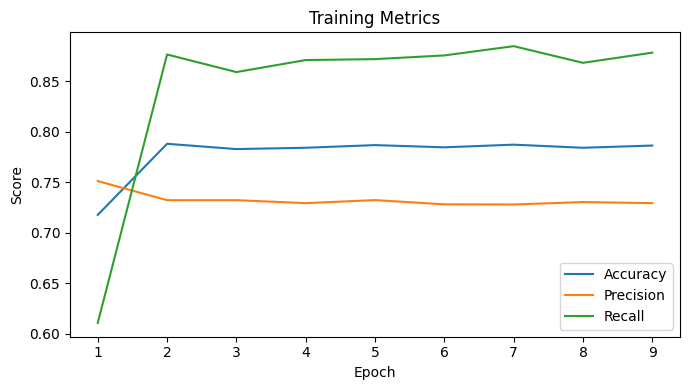

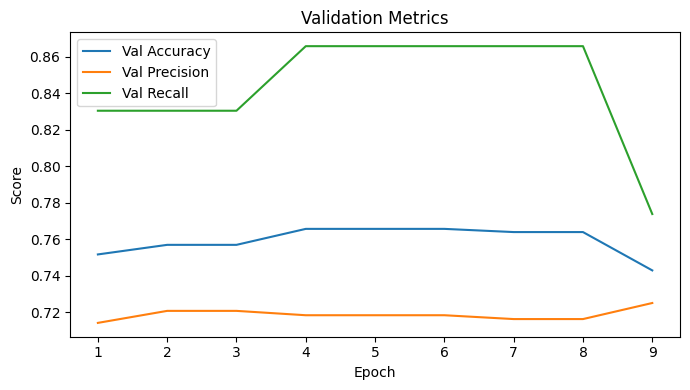

In [17]:

epochs = range(1, len(history_final.history['accuracy']) + 1)

# Training metrics
plt.figure(figsize=(7,4))
plt.plot(epochs, history_final.history['accuracy'],  label='Accuracy')
plt.plot(epochs, history_final.history['precision'], label='Precision')
plt.plot(epochs, history_final.history['recall'],    label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Metrics')
plt.legend()
plt.tight_layout()
plt.show()

# Validation metrics
plt.figure(figsize=(7,4))
plt.plot(epochs, history_final.history['val_accuracy'],  label='Val Accuracy')
plt.plot(epochs, history_final.history['val_precision'], label='Val Precision')
plt.plot(epochs, history_final.history['val_recall'],    label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.legend()
plt.tight_layout()
plt.show()


## Performance on the Unseen Test Data

This section evaluates the **final trained FFNN_Large model** on unseen test data to verify how well it generalizes beyond the training set.  
The model’s key performance metrics **Accuracy**, **Precision**, **Recall**, and **F1-Score** are computed and visualized for easy comparison.

- **Accuracy:** Measures the overall proportion of correct predictions.  
- **Precision:** Indicates how many of the predicted “Satisfied” passengers were actually satisfied.  
- **Recall:** Reflects how many of the true “Satisfied” passengers were successfully identified by the model.  
- **F1-Score:** Combines precision and recall into a single balanced metric, useful for imbalanced datasets.

The bar chart below visually compares these metrics on the test dataset.  
It provides a quick insight into the model’s **real-world performance**, revealing whether it maintains consistency across all key measures or overfits during training.


In [18]:
test_loss, test_accuracy, test_precision, test_recall = model_F_large.evaluate(Xte_F_s, yte_F, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

Test Loss: 0.5011218786239624
Test Accuracy: 0.7748251557350159
Test Precision: 0.7194244861602783
Test Recall: 0.8720930218696594


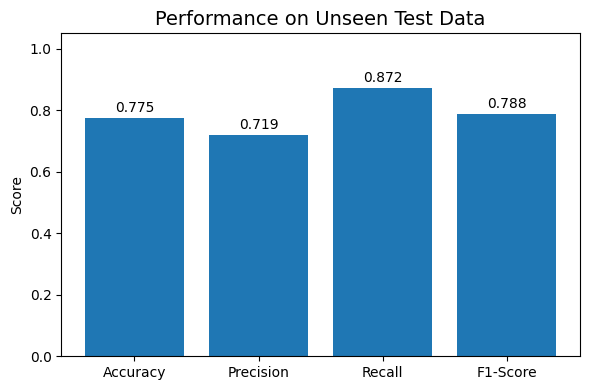

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Compute F1
eps = 1e-8
test_f1 = 2 * test_precision * test_recall / (test_precision + test_recall + eps)

# --- Plot Performance Metrics ---
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [test_accuracy, test_precision, test_recall, test_f1]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values)
plt.ylim(0, 1.05)
plt.title("Performance on Unseen Test Data", fontsize=14)
plt.ylabel("Score")

# Annotate bars with values
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## Inference Examples

This step demonstrates the **inference function** in action, showing how the trained model makes predictions from **raw, non-encoded user inputs**.

Two example passenger profiles were tested these examples illustrate how the model interprets real-world inputs and returns **clear natural language outputs** indicating whether a passenger is likely to be satisfied or dissatisfied based on their flight characteristics and review sentiment.


In [20]:
raw_ex1 = {
    "Verified": "Trip Verified",
    "Traveller_Type": "Family Leisure",
    "Class": "Economy Class",
    "Sentiment": "Neutral",
}
print(predict_satisfaction_F_raw(raw_ex1)["message"])

# Example 2: Not verified + Solo Leisure + Economy + Negative
raw_ex2 = {
    "Verified": "Not Verified",
    "Traveller_Type": "Solo Leisure",
    "Class": "Economy Class",
    "Sentiment": "Positive",
}
print(predict_satisfaction_F_raw(raw_ex2)["message"])

Prediction: **Dissatisfied** (probability of satisfaction = 0.233, threshold = 0.50).
Prediction: **Satisfied** (probability of satisfaction = 0.782, threshold = 0.50).


## Explainable AI - SHAP

To enhance model transparency, **SHAP** was applied to interpret how each feature contributes to the model’s predictions of passenger satisfaction.

**What this step does:**
1. Converts the scaled training and testing data into DataFrames with clear feature labels for interpretability.  
2. Defines a `predict_fn` function that allows SHAP to query the model for prediction probabilities.  
3. Samples 100 instances from the training set as a **background reference**, representing the typical data distribution.  
4. Initializes a **SHAP Explainer**, which automatically selects the most suitable algorithm for the trained Keras model.  
5. Computes **SHAP values** for the test set to quantify each feature’s contribution to the model’s output.

**Visual Outputs:**
- **Summary Plot:** Displays the magnitude and direction of influence for each feature on the prediction outcome.  
Features with higher SHAP values have a stronger effect on determining satisfaction or dissatisfaction.  
- **Bar Plot:** Ranks features by their **average impact**, providing a clear overview of which inputs most influence predictions.  
- **Force Plot:** Offers a **local explanation** for an individual prediction (e.g., one passenger), showing how each feature pushes the result toward “Satisfied” or “Dissatisfied.”

**Why it matters:**  
SHAP ensures **interpretability and accountability**, making it possible to explain complex neural network predictions in human-understandable terms.


## SHAP Output Interpretation

The SHAP visualizations above explain how different encoded features influenced the **FFNN_Large model’s predictions** for passenger satisfaction.

### 1. **Global SHAP Summary Plot (Top Figure)**
- The scatter plot shows **how each feature impacts model output** (positive or negative influence).
- Each point represents one passenger sample.
- **Color intensity** reflects the feature’s value:
  - Red = higher encoded value  
  - Blue = lower encoded value  
- **Interpretation:**  
  - **Sentiment_enc** has the strongest impact — higher sentiment values increase the likelihood of satisfaction.  
  - **Traveller_Type_enc** and **Class_enc** show moderate influence, while **Verified_enc** contributes the least overall.

### 2. **Feature Importance Bar Plot (Middle Figure)**
- This plot ranks features by their **average absolute SHAP values** indicating overall importance.
- The model relies most heavily on:
  1. **Sentiment_enc** – passengers expressing positive sentiment are more likely to be satisfied.  
  2. **Traveller_Type_enc** – certain traveler types (e.g., Family Leisure) correlate with higher satisfaction.  
  3. **Class_enc** and **Verified_enc** have smaller but still measurable effects.  

### 3. **Local SHAP Force Plot (Bottom Figure)**
- This explains an individual passenger’s prediction (local explanation).  
- The base value represents the model’s average predicted satisfaction.  
- **Red arrows** indicate features that *increase* the predicted satisfaction score (push right).  
- **Blue arrows** indicate features that *decrease* satisfaction (push left).  

### **Overall Insight**
The SHAP results reveal that **sentiment of the review** is the most decisive factor in determining satisfaction, followed by **traveler type** and **class**.  
Verification status has minimal effect, suggesting that passengers’ expressed emotions and travel context are stronger predictors of satisfaction than whether their trip was verified.


ExactExplainer explainer: 716it [00:14, 22.46it/s]                         


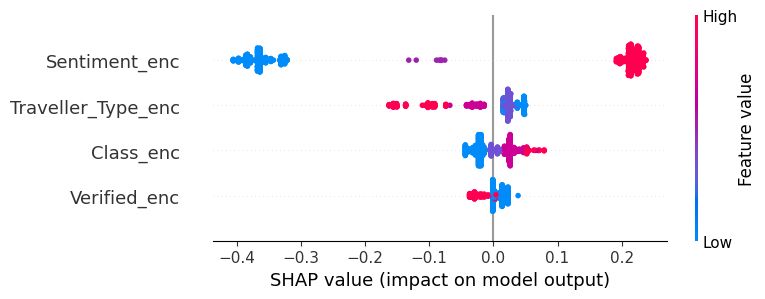

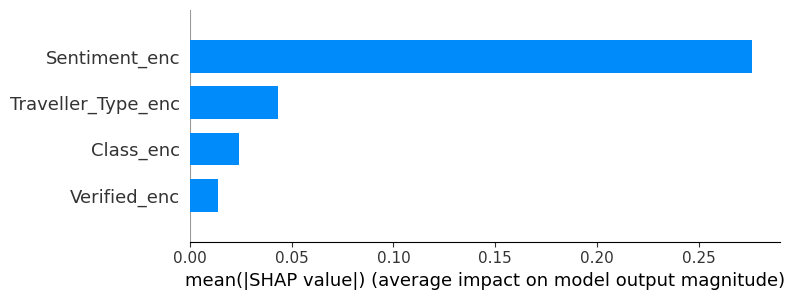

In [21]:
X_train_scaled_df = pd.DataFrame(Xtr_F_s, columns=FEATURE_SET_F)
X_test_scaled_df  = pd.DataFrame(Xte_F_s,  columns=FEATURE_SET_F)


def predict_fn(X):
    return model_F_large.predict(X, verbose=0).ravel()

background = shap.sample(X_train_scaled_df, 100, random_state=42)

# Let SHAP pick the best algorithm for your Keras model
explainer = shap.Explainer(model_F_large, background)

# Compute SHAP values on the test set (scaled!)
shap_values = explainer(X_test_scaled_df)

# Global summary (bar of mean |SHAP|)
shap.summary_plot(shap_values.values, X_test_scaled_df, feature_names=FEATURE_SET_F)
shap.summary_plot(shap_values.values, X_test_scaled_df, feature_names=FEATURE_SET_F, plot_type='bar')
# Local explanation (row i)
i = 0
shap.initjs()
shap.plots.force(shap_values[i], feature_names=FEATURE_SET_F)



## Explainable AI- LIME

After using SHAP for global interpretation, **LIME** was applied to provide a **local explanation** for a single prediction made by the model.  
LIME helps understand *why* a specific prediction (Satisfied or Dissatisfied) was made by approximating the model locally with a simpler, interpretable surrogate model.

### **Process Overview**
1. **Prediction Function:**  
   A custom `predict_fn2` function was created to return probabilities for both classes `Dissatisfied` and `Satisfied`.  
   LIME requires a 2-column probability output (`[P(class0), P(class1)]`) to generate explanations.

2. **LIME Explainer Setup:**  
   The `LimeTabularExplainer` was initialized using the **scaled training data** and the feature set  
   `["Verified_enc", "Traveller_Type_enc", "Class_enc", "Sentiment_enc"]`.  


3. **Explanation Instance:**  
   For a specific test instance (`j = 1`), LIME perturbed the input data around that point, observed the resulting predictions,  
   and trained a simple interpretable model (like a linear regression) to approximate how each feature affects the output.

4. **Generated Output:**
   - Displays **prediction probabilities** .  
   - Visualizes the contribution of each feature toward the final decision.  
   - Lists the **direction and strength** of each feature’s effect numerically.




## **LIME Output Interpretation**

In the shown LIME visualization:

- The model predicts the passenger is **Dissatisfied (0.83)**, with a **0.17 probability of being Satisfied**.  
- **Feature Contributions:**  
  - **Sentiment_enc (+0.25)** pushes the prediction slightly toward satisfaction, suggesting a neutral or positive tone increases satisfaction.  
  - **Traveller_Type_enc (-0.046)**, **Verified_enc (-0.030)**, and **Class_enc (+0.028)** have smaller effects, indicating that traveler type and verification status contributed slightly toward dissatisfaction.  
- **Color Coding:**  
  - **Orange bars** = features pushing the prediction toward “Satisfied.”  
  - **Blue bars** = features pushing the prediction toward “Dissatisfied.”

### **Conclusion**
- LIME confirms that **sentiment remains the dominant driver** of satisfaction, aligning with SHAP findings.  
- Other features such as traveler type and verification have smaller but still directional effects.  
- Together, these methods provide both a **global (SHAP)** and **local (LIME)** understanding of how the model forms its predictions, improving interpretability and trustworthiness.

In [22]:
# LIME expects predict_proba with 2 columns: [P(class0), P(class1)]
def predict_fn2(X):
    p1 = model_F_large.predict(X, verbose=0).ravel()
    p0 = 1.0 - p1
    return np.vstack([p0, p1]).T

# LIME explainer on the scaled training data
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr_F_s,     # numpy array
    feature_names=FEATURE_SET_F,
    class_names=['Dissatisfied', 'Satisfied'],
    mode='classification',
    discretize_continuous=False       #inputs are already scaled numeric
)

j = 1  # explain this test row
exp = explainer_lime.explain_instance(
    data_row=Xte_F_s[j],        # numpy array row
    predict_fn=predict_fn2,
    num_features=len(FEATURE_SET_F)   # show all features
)

# In a notebook, this renders an HTML view:
exp.show_in_notebook()
print("LIME explanation (feature, effect):")
for feat, val in exp.as_list():
    print(f"{feat}: {val:+.4f}")

LIME explanation (feature, effect):
Sentiment_enc: +0.2500
Traveller_Type_enc: -0.0466
Verified_enc: -0.0303
Class_enc: +0.0280
